# Módulo 33 - K-Means
## Segmentação de clientes

### Contexto
A segmentação de clientes é uma estratégia essencial para empresas que desejam compreender melhor o perfil e o comportamento de seus consumidores. Estudos em marketing e ciência de dados mostram que características como idade, renda anual, gênero e padrões de gastos variam significativamente entre grupos de clientes, refletindo necessidades e preferências distintas. A identificação desses grupos permite o desenvolvimento de ações mais direcionadas, como campanhas de marketing personalizadas e ofertas sob medida, aumentando a eficiência e o retorno das estratégias comerciais.

### Objetivo Geral
Aplicar a técnica de clusterização K-means para segmentar clientes com base em suas características demográficas e comportamentais, utilizando dados coletados de um conjunto de 200 clientes.

### Objetivos Complementares
* **Pré-processamento pt-1:** Verificar os tipos de variáveis disponíveis no dataset e
limpeza dos dados e exclusão de registros com informações faltantes.
* **Análise exploratória & descritiva:** Identificar possíveis agrupamentos de clientes por meio de suas características demográficas e de consumo.
* **Pré-processamento pt-2:** Padronizar os dados para garantir comparabilidade entre as variáveis;Realizar visualizações para melhor compreensão dos padrões e distribuição dos clientes.
* **Modelagem:** Aplicar o algoritmo K-means, definindo o número de clusters de acordo com a análise exploratória e os objetivos do negócio.
* **Avaliação:** Analisar os centroides dos clusters, dispersão dos grupos.

### Base de Dados
A base de dados contém 200 registros com  as seguintes features de acordo com a **Tabela 1**.
|             Features           | Tipo   |   Nulos | Mínimo   | Máximo   |
|:-----------------------|:-------|--------:|:---------|:---------|
| CustomerID             | int64  |       0 | 1        | 200      |
| Gender                 | object |       0 | Female   | Male     |
| Age                    | int64  |       0 | 18       | 70       |
| Annual Income (k$)     | int64  |       0 | 15       | 137      |
| Spending Score (1-100) | int64  |       0 | 1        | 99       |
**Tabela 1**




### 📂 1. Importação de Bibliotecas & dataload

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Leitura dos dados
df = pd.read_csv('/home/akel/PycharmProjects/EBAC/dados/Mall_Customers.csv')
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 🧹 2. Pré-processamento pt-1: Tipos e limpeza de dados

In [2]:
# remover coluna CustomerID: Não carrega significado sobre o comportamento ou perfil do cliente.( não é previsível)
df.drop('CustomerID',axis=1,inplace=True)

#renomear colunas para melhor manipulação:
df.rename(columns={'Annual Income (k$)': 'annual_income'}, inplace=True)
df.rename(columns={'Spending Score (1-100)': 'score'}, inplace=True)

#renomear variavael categorica
#df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

resume=pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Mínimo': df.min(),
    'Máximo': df.max()      
})
print(resume.to_markdown())

|               | Tipo   |   Nulos | Mínimo   | Máximo   |
|:--------------|:-------|--------:|:---------|:---------|
| Gender        | object |       0 | Female   | Male     |
| Age           | int64  |       0 | 18       | 70       |
| annual_income | int64  |       0 | 15       | 137      |
| score         | int64  |       0 | 1        | 99       |


```markdown
📌 Não há valores nulos nos dados. 

```

### 📊 3. Análise exploratória e descritiva


 Estatísticas descritivas:


,Age,annual_income,score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


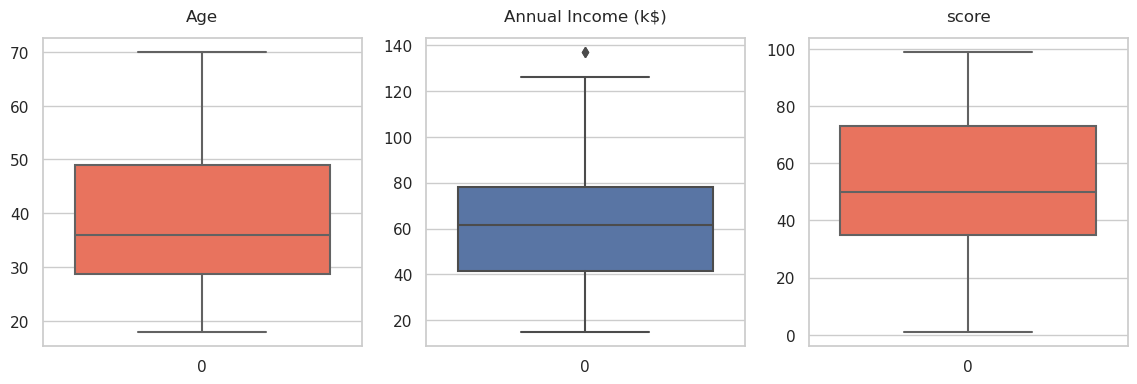

In [118]:
# Estatísticas descritivas
print("\n Estatísticas descritivas:")
display(df.describe())

fig, axs = plt.subplots(1,3, figsize=(14, 4))

sns.boxplot(data=df['Age'],color='tomato',ax=axs[ 0])
axs[0].set_title("Age", pad=12)

sns.boxplot(data=df['annual_income'],ax=axs[ 1])
axs[ 1].set_title("Annual Income (k$)", pad=12)

sns.boxplot(data=df['score'], orient='v',color='tomato',ax=axs[ 2])
axs[ 2].set_title("score", pad=12)
plt.show()

```markdown
📌 **Considerações parciais**: Não foram observados outliers na features
```

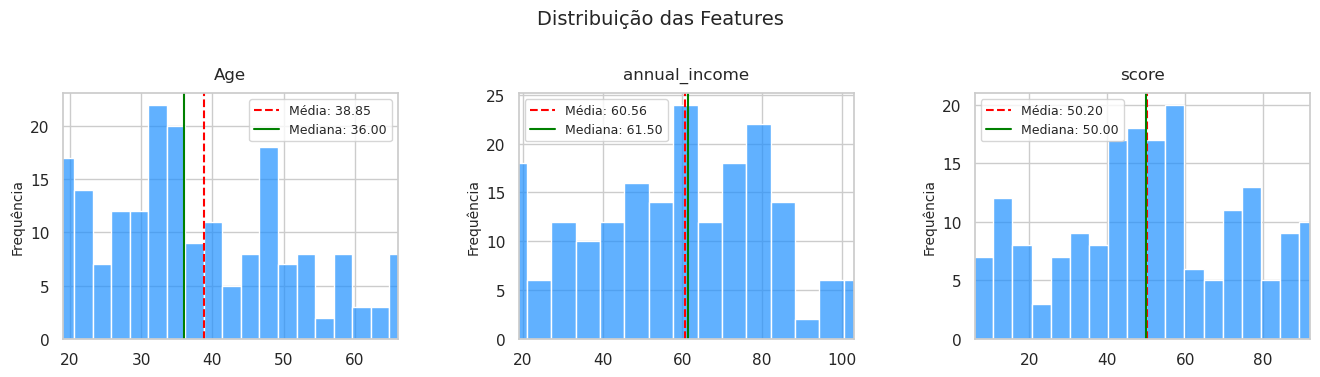

=======Teste Normalidade Shapiro-Wil=====
Shapiro-Wilk (Age): p=0.000
Distribuição  NÃO é normal.
Shapiro-Wilk (annual_income): p=0.004
Distribuição  NÃO é normal.
Shapiro-Wilk (score): p=0.000
Distribuição  NÃO é normal.


In [114]:
# Configurar o estilo dos gráficos
sns.set(style="whitegrid")
# Lista das colunas e títulos
colunas = list(df.select_dtypes(include='number').columns)

# Defina o número de bins para cada variável
bins_var = [20,20,20]

# Histogramas (bins e counts) usando list comprehensions com bins variáveis
hist_bins_counts = [
    np.histogram(df[c].dropna(), bins=b) for c, b in zip(colunas, bins_var)
]

# DataFrame dos histogramas
histogram_df = pd.concat([
    pd.DataFrame({
        'bin_start': bins[:-1],
        'bin_end': bins[1:],
        'count': counts,
        'variable': var
    })
    for (counts, bins), var in zip(hist_bins_counts, colunas)
], ignore_index=True)

# Plot dos histogramas em subplots sem for e sem função customizada
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

list(map(lambda i: [
    sns.histplot(df[colunas[i]], color='dodgerblue', bins=bins_var[i], alpha=0.7, ax=axes[i]),
    axes[i].axvline(df[colunas[i]].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Média: {df[colunas[i]].mean():.2f}'),
    axes[i].axvline(df[colunas[i]].median(), color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {df[colunas[i]].median():.2f}'),
    axes[i].set_title(colunas[i], fontsize=12, pad=10),
    axes[i].set_xlabel(''),
    axes[i].set_ylabel('Frequência', fontsize=10),
    axes[i].legend(fontsize=9),
    axes[i].set_xlim(df[colunas[i]].quantile(0.05), df[colunas[i]].quantile(0.95))
], range(len(colunas))))

plt.tight_layout(pad=3.0)
plt.suptitle('Distribuição das Features', y=1.02, fontsize=14)
plt.show()


from scipy.stats import shapiro
print('=======Teste Normalidade Shapiro-Wilk=====')
for i in range(3):
    stat, p = shapiro(df[colunas[i]])
    print(f"Shapiro-Wilk ("+colunas[i] +f"): p={p:.3f}")
    if p < 0.05:
        print("Distribuição  NÃO é normal.")
    else:
        print("Distribuição PODE ser normal.")



```markdown
📌 Considerações parciais: Distribuição não é normal (Teste shapiro-wilk de normalidade(anexo). Assimetrias são observadas em todas as distribuições, com algumas prevalências para jovens adultos  (30-36 anos), renda entre 45- 82k e score entre 45-60.
```

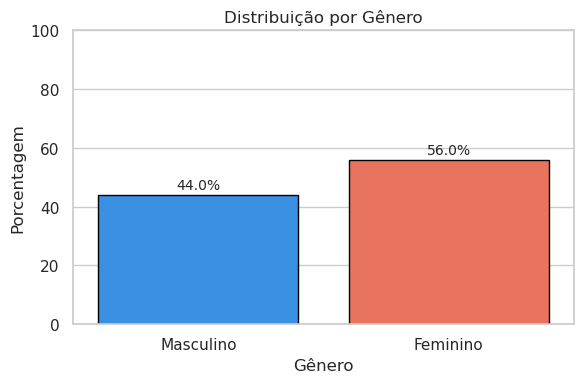

In [38]:
df2=df.copy()
df2['Gender'] = df2['Gender'].map({'Female': 0, 'Male': 1})
p1 = df2['Gender'].value_counts(normalize=True) * 100

df_bar = pd.DataFrame({
    'Gênero': ['Masculino', 'Feminino'],
    'Porcentagem': [p1[1], p1[0]]})

# Plot com seaborn
plt.figure(figsize=(6, 4))
sns.barplot(data=df_bar, x='Gênero', y='Porcentagem', palette=['dodgerblue', 'tomato'], edgecolor='black')

# Título e anotações
plt.title('Distribuição por Gênero')
plt.ylim(0, 100)

# Adiciona os valores sobre as barras
for i, row in df_bar.iterrows():
    plt.text(i, row['Porcentagem'] + 1, f"{row['Porcentagem']:.1f}%", 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

>📌 **Considerações parciais:** O gênero feminino é ligeiramente superior (56%) na base de dados de clientes.

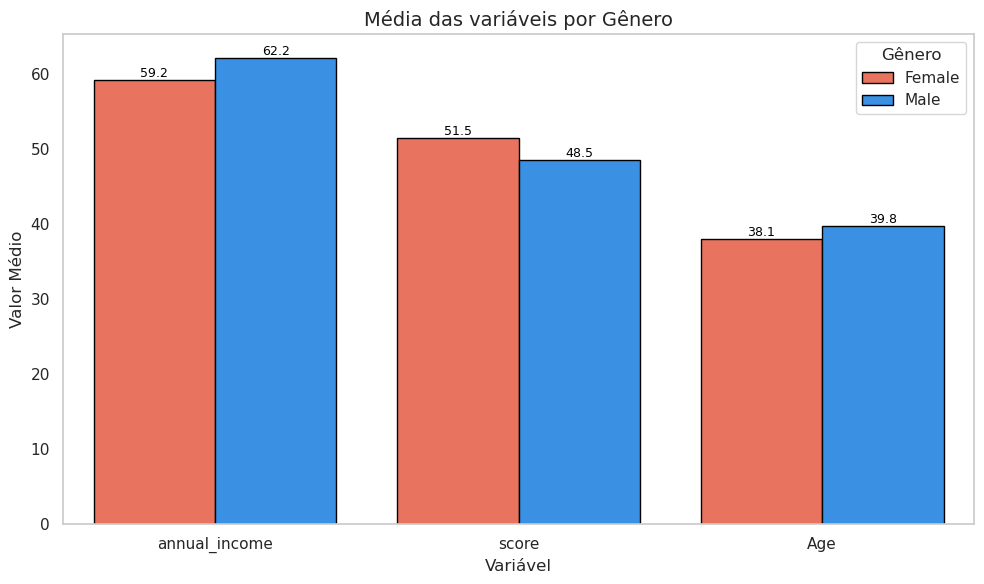

In [37]:
# agrupamento para comparar generos
df2=df.copy()
# Preparar DataFrame com médias agrupadas
means = df2.groupby("Gender")[["annual_income", "score", "Age"]].mean().reset_index()

# organizando para colunas
means_melted = means.melt(id_vars="Gender", 
                          value_vars=["annual_income", "score", "Age"], 
                          var_name="Variável", 
                          value_name="Média")

# Gráfico de barras
plt.figure(figsize=(10, 6))
ax=sns.barplot(data=means_melted, x="Variável", y="Média", hue="Gender", palette=['tomato','dodgerblue' ], edgecolor='black')

plt.title("Média das variáveis por Gênero", fontsize=14)
plt.ylabel("Valor Médio")
plt.xlabel("Variável")
plt.legend(title="Gênero")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adicionar os valores em cima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}',  # texto com uma casa decimal
                (p.get_x() + p.get_width() / 2, height),  # posição (centro da barra, topo)
                ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

>📌 **Considerações parciais**: A distribuição da features baseada nos gênero, mostra que as diferenças são pequenas. Em média:
>* Homens têm renda ligeiramente maior(5%);
>* Mulheres tem um consumo ligeiramente maior(6%);
>* Homens são ligeiramente mais velhos(4%);

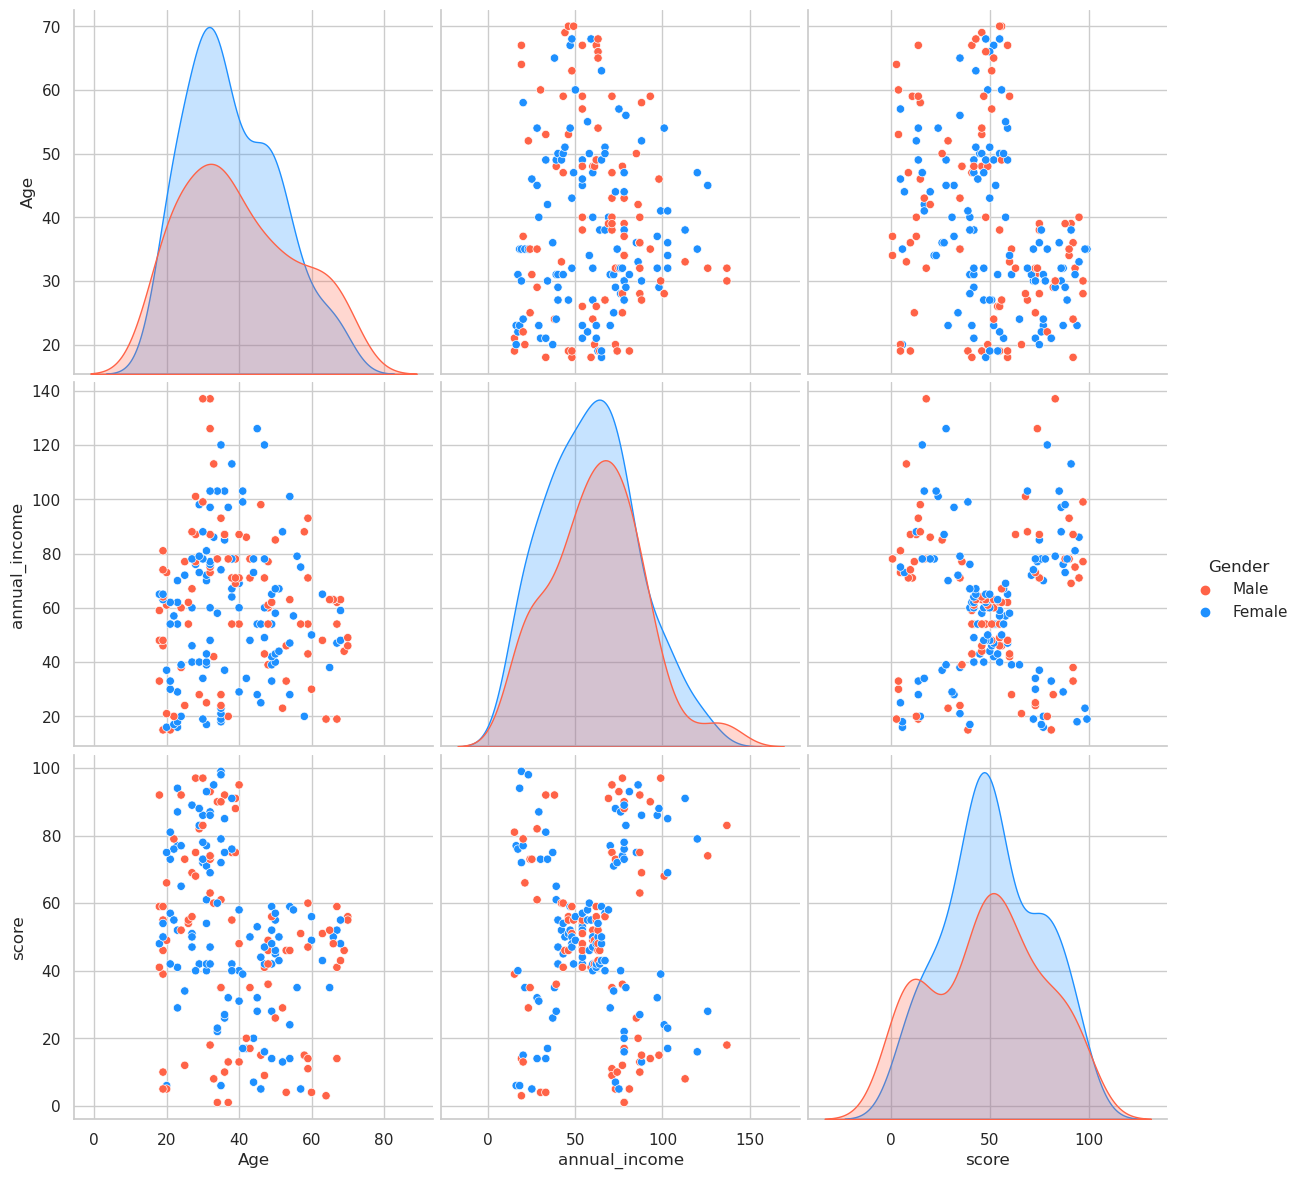

In [117]:
sns.set(style="whitegrid")

sns.pairplot(df, hue="Gender",height=4, palette=['tomato','dodgerblue' ], diag_kind="kde")
pair.fig.suptitle("Análise de Pares por Gênero", fontsize=16, y=1.02)

pair._legend.set_bbox_to_anchor((0.5, 1.05))
pair._legend.set_title("Gênero")

pair._legend._loc = 9  # centralizado no topopair._legend.set_title("Gênero")
plt.show();

>📌 **Considerações parciais:**
>
>* **Idade x renda :** Não há uma correlação clara,portanto jovens e idosas podem ter tanto rendas baixas quanto altas.
>* **Idade x Score :** sugerem diferentes padrões de consumo entre jovem e pessoas mais velhas. Não observamos score alto (>60) em pessoas acima de
>~40

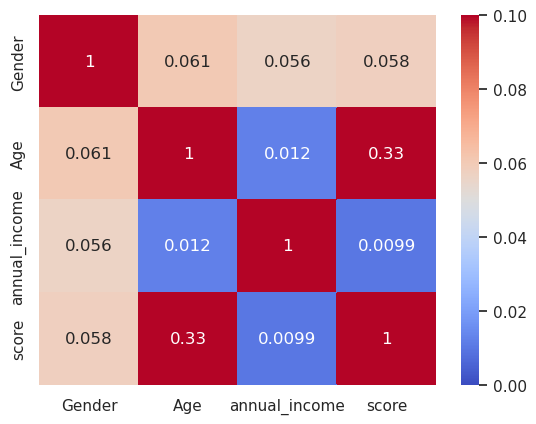

In [8]:
df2=df.copy()
df2['Gender'] = df2['Gender'].map({'Male': 0, 'Female': 1})
cm = df2.corr()
sns.heatmap(abs(cm), annot=True, cmap='coolwarm', vmin=-0.0, vmax=0.1)
colunas = list(df.select_dtypes(include='number').columns)

>📌 **Considerações parciais:**
>Apenas a correlação entre **Age** e **Score** mostram uma correlação negativa significativa(-0.33). Pessoas mais jovem tendem a ter um score maior.

### ⚙️ 5. Pré-processamento pt-2: Padronização dos dados